In [1]:
from langchain_ollama import ChatOllama
llm = ChatOllama(model="deepseek-r1:14b", temperature=0)
llm_json_mode = ChatOllama(model="deepseek-r1:14b", temperature=0, format="json")

In [2]:
msg = llm.invoke("什麼是PCB?")
msg.content

'<think>\n\n</think>\n\nPCB 是 Printed Circuit Board 的缩写，中文翻译为“印制电路板”。它是一种用于电子设备的基板，上面印刷有导电线路和元件，用于连接各种电子元器件，实现电路功能。\n\n### PCB 的主要特点：\n1. **高密度**：通过多层设计和微细线路，PCB 可以在很小的空间内集成大量电子元件。\n2. **可靠性**：相比传统的点对点接线，PCB 的导电性能更稳定，抗干扰能力更强。\n3. **标准化**：PCB 设计和制造有严格的标准，便于大规模生产。\n\n### PCB 的分类：\n1. **单层 PCB**：只有一层导电材料，适合简单的电路。\n2. **双层 PCB**：两层导电材料，适合中等复杂度的电路。\n3. **多层 PCB**：超过两层，适合高密度、高性能的需求。\n\n### PCB 的应用：\n- **电子设备**：如手机、电脑、电视等。\n- **汽车电子**：用于发动机控制、刹车系统等。\n- **工业自动化**：用于各种控制系统和仪器仪表。\n- **医疗设备**：用于生命体征监测和其他精密设备。\n\nPCB 是现代电子技术的核心，广泛应用于各个领域。'

In [5]:
import json
p = """Your goal is to genetate target web search query

The query will gather information related to a specific topic.

Topic: cats

Return your query in a JSON object.
{{
    "query": "string",
    "aspect": "string",
    "rationale": "string"
}}
"""
msg = llm_json_mode.invoke(p)
query = json.loads(msg.content)
query


{'query': 'cats',
 'aspect': 'general information about cats',
 'rationale': 'Cats are popular pets, and understanding their behavior, care, and history is essential for cat owners.'}

In [6]:
msg = llm.invoke("給我 scaling laws for RL models 的摘要")
msg.content


'<think>\n嗯，我现在要理解一下Scaling Laws for RL Models的摘要。首先，摘要里提到他们研究了在强化学习中，模型规模、数据量和计算资源对性能的影响。这听起来挺重要的，因为现在大模型越来越流行，但背后的规律还不清楚。\n\n然后，他们分析了各种RL算法，比如DQN、PPO、A2C这些，发现当参数变多时，样本效率提高了，也就是说用更少的数据就能学到更好的策略。这点我记得以前学过，更大的网络可能有更强的表达能力，所以学习更快。\n\n接下来，计算资源对收敛速度的影响更大，尤其是在监督学习中，更多的GPU时间能显著提升性能。不过在RL里，效果不如监督学习明显，这可能是因为RL本身需要探索和环境互动，单纯增加算力不一定直接带来收益。\n\n然后，他们提出了一个缩放定律，说模型的最优参数数量与训练数据量成正比，而计算资源对最终结果的影响较小。这点有点反直觉，因为通常我们会觉得更多的计算资源能带来更好的效果，但这里显示在RL中可能不是这样。\n\n最后，结论是设计更大的模型和收集更多数据对提升性能更重要，而不是一味地增加计算资源。这给了我一个方向，未来研究RL时应该更关注模型规模和数据量，而不是仅仅堆算力。\n\n不过，我有点困惑的是，为什么在监督学习中计算资源影响大，而RL中则不明显？是不是因为RL需要更多的探索，导致单纯增加GPU时间并不能显著提升效果？或者可能是因为RL任务本身的多样性更大，计算资源的使用效率不如监督学习高？\n\n另外，缩放定律的具体形式是怎样的呢？比如，参数数量和数据量之间的比例是多少？有没有具体的数学表达式或图表来说明这一点？\n\n还有，他们测试了哪些环境？这些结果是否适用于所有类型的RL任务，还是特定于某些环境？如果只在特定环境中有效，那这个结论的普适性如何？\n\n最后，我应该怎样应用这些发现到实际项目中呢？是不是应该优先增大模型规模和收集更多的训练数据，而不是急于购买更多GPU资源？当然，这也取决于项目的资源限制和目标。\n</think>\n\nScaling Laws for RL Models 的研究揭示了在强化学习（RL）中，模型性能受模型规模、数据量和计算资源的影响。以下是摘要的总结：\n\n1. **研究重点**：探讨了模型参数数量、训练数据量和计算资源对RL算法性能的影响。\n\n2. **发现与结

## build deep research

In [69]:
from langchain_ollama import ChatOllama

### LLM
# local_llm = "llama3.2"
local_llm = "qwen2.5:14b"
llm = ChatOllama(model=local_llm, temperature=0)
llm_json_mode = ChatOllama(model=local_llm, temperature=0, format="json")

In [70]:
import operator
from dataclasses import dataclass, field
from typing_extensions import TypedDict, Annotated, Literal

@dataclass(kw_only=True)
class SummaryState:
    research_topic: str = field(default=None) # Report topic     
    search_query: str = field(default=None) # Search query
    web_research_results: Annotated[list, operator.add] = field(default_factory=list) 
    sources_gathered: Annotated[list, operator.add] = field(default_factory=list) 
    research_loop_count: int = field(default=0) # Research loop count
    running_summary: str = field(default=None) # Final report

@dataclass(kw_only=True)
class SummaryStateInput(TypedDict):
    research_topic: str = field(default=None) # Report topic     

@dataclass(kw_only=True)
class SummaryStateOutput(TypedDict):
    running_summary: str = field(default=None) # Final report

In [71]:
## prompt 

### Query Writer
query_writer_instructions="""Your goal is to generate a targeted web search query.
The query will gather information related to a specific topic.

<TOPIC>
{research_topic}
</TOPIC>

<FORMAT>
Format your response as a JSON object with ALL three of these exact keys:
   - "query": The actual search query string
   - "aspect": The specific aspect of the topic being researched
   - "rationale": Brief explanation of why this query is relevant
</FORMAT>

<EXAMPLE>
Example output:
{{
    "query": "machine learning transformer architecture explained",
    "aspect": "technical architecture",
    "rationale": "Understanding the fundamental structure of transformer models"
}}
</EXAMPLE>

Provide your response in JSON format:"""

summarizer_instructions="""
<GOAL>
Generate a high-quality summary of the web search results and keep it concise / related to the user topic.
</GOAL>

<REQUIREMENTS>
When creating a NEW summary:
1. Highlight the most relevant information related to the user topic from the search results
2. Ensure a coherent flow of information

When EXTENDING an existing summary:                                                                                                                 
1. Read the existing summary and new search results carefully.                                                    
2. Compare the new information with the existing summary.                                                         
3. For each piece of new information:                                                                             
    a. If it's related to existing points, integrate it into the relevant paragraph.                               
    b. If it's entirely new but relevant, add a new paragraph with a smooth transition.                            
    c. If it's not relevant to the user topic, skip it.                                                            
4. Ensure all additions are relevant to the user's topic.                                                         
5. Verify that your final output differs from the input summary.                                                                                                                                                            
< /REQUIREMENTS >

< FORMATTING >
- Start directly with the updated summary, without preamble or titles. Do not use XML tags in the output.  
< /FORMATTING >"""

reflection_instructions = """You are an expert research assistant analyzing a summary about {research_topic}.

<GOAL>
1. Identify knowledge gaps or areas that need deeper exploration
2. Generate a follow-up question that would help expand your understanding
3. Focus on technical details, implementation specifics, or emerging trends that weren't fully covered
</GOAL>

<REQUIREMENTS>
Ensure the follow-up question is self-contained and includes necessary context for web search.
</REQUIREMENTS>

<FORMAT>
Format your response as a JSON object with these exact keys:
- knowledge_gap: Describe what information is missing or needs clarification
- follow_up_query: Write a specific question to address this gap
</FORMAT>

<EXAMPLE>
Example output:
{{
    "knowledge_gap": "The summary lacks information about performance metrics and benchmarks",
    "follow_up_query": "What are typical performance benchmarks and metrics used to evaluate [specific technology]?"
}}
</EXAMPLE>

Provide your analysis in JSON format:"""

In [75]:
## Graph

import json

from typing_extensions import Literal

from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.runnables import RunnableConfig
from langchain_ollama import ChatOllama
from langgraph.graph import START, END, StateGraph

from assistant.configuration import Configuration, SearchAPI
from assistant.utils import deduplicate_and_format_sources, tavily_search, format_sources, perplexity_search, duckduckgo_search
from assistant.state import SummaryState, SummaryStateInput, SummaryStateOutput
from assistant.prompts import query_writer_instructions, summarizer_instructions, reflection_instructions

# Nodes
def generate_query(state: SummaryState, config: RunnableConfig):
    """ Generate a query for web search """

    # Format the prompt
    query_writer_instructions_formatted = query_writer_instructions.format(research_topic=state.research_topic)

    # Generate a query
    configurable = Configuration.from_runnable_config(config)
    llm_json_mode = ChatOllama(base_url=configurable.ollama_base_url, model=configurable.local_llm, temperature=0, format="json")
    result = llm_json_mode.invoke(
        [SystemMessage(content=query_writer_instructions_formatted),
        HumanMessage(content=f"Generate a query for web search:")]
    )
    query = json.loads(result.content)

    return {"search_query": query['query']}

def web_research(state: SummaryState, config: RunnableConfig):
    """ Gather information from the web """

    # Configure
    configurable = Configuration.from_runnable_config(config)

    # Handle both cases for search_api:
    # 1. When selected in Studio UI -> returns a string (e.g. "tavily")
    # 2. When using default -> returns an Enum (e.g. SearchAPI.TAVILY)
    if isinstance(configurable.search_api, str):
        search_api = configurable.search_api
    else:
        search_api = configurable.search_api.value

    # Search the web
    if search_api == "tavily":
        search_results = tavily_search(state.search_query, include_raw_content=True, max_results=1)
        search_str = deduplicate_and_format_sources(search_results, max_tokens_per_source=1000, include_raw_content=True)
    elif search_api == "perplexity":
        search_results = perplexity_search(state.search_query, state.research_loop_count)
        search_str = deduplicate_and_format_sources(search_results, max_tokens_per_source=1000, include_raw_content=False)
    elif search_api == "duckduckgo":
        search_results = duckduckgo_search(state.search_query, max_results=3, fetch_full_page=configurable.fetch_full_page)
        search_str = deduplicate_and_format_sources(search_results, max_tokens_per_source=1000, include_raw_content=True)
    else:
        raise ValueError(f"Unsupported search API: {configurable.search_api}")

    return {"sources_gathered": [format_sources(search_results)], "research_loop_count": state.research_loop_count + 1, "web_research_results": [search_str]}

def summarize_sources(state: SummaryState, config: RunnableConfig):
    """ Summarize the gathered sources """

    # Existing summary
    existing_summary = state.running_summary

    # Most recent web research
    most_recent_web_research = state.web_research_results[-1]

    # Build the human message
    if existing_summary:
        human_message_content = (
            f"<User Input> \n {state.research_topic} \n <User Input>\n\n"
            f"<Existing Summary> \n {existing_summary} \n <Existing Summary>\n\n"
            f"<New Search Results> \n {most_recent_web_research} \n <New Search Results>"
        )
    else:
        human_message_content = (
            f"<User Input> \n {state.research_topic} \n <User Input>\n\n"
            f"<Search Results> \n {most_recent_web_research} \n <Search Results>"
        )

    # Run the LLM
    configurable = Configuration.from_runnable_config(config)
    llm = ChatOllama(base_url=configurable.ollama_base_url, model=configurable.local_llm, temperature=0)
    result = llm.invoke(
        [SystemMessage(content=summarizer_instructions),
        HumanMessage(content=human_message_content)]
    )

    running_summary = result.content

    # TODO: This is a hack to remove the <think> tags w/ Deepseek models
    # It appears very challenging to prompt them out of the responses
    while "<think>" in running_summary and "</think>" in running_summary:
        start = running_summary.find("<think>")
        end = running_summary.find("</think>") + len("</think>")
        running_summary = running_summary[:start] + running_summary[end:]

    return {"running_summary": running_summary}

def reflect_on_summary(state: SummaryState, config: RunnableConfig):
    """ Reflect on the summary and generate a follow-up query """

    # Generate a query
    configurable = Configuration.from_runnable_config(config)
    llm_json_mode = ChatOllama(base_url=configurable.ollama_base_url, model=configurable.local_llm, temperature=0, format="json")
    result = llm_json_mode.invoke(
        [SystemMessage(content=reflection_instructions.format(research_topic=state.research_topic)),
        HumanMessage(content=f"Identify a knowledge gap and generate a follow-up web search query based on our existing knowledge: {state.running_summary}")]
    )
    follow_up_query = json.loads(result.content)

    # Get the follow-up query
    query = follow_up_query.get('follow_up_query')

    # JSON mode can fail in some cases
    if not query:

        # Fallback to a placeholder query
        return {"search_query": f"Tell me more about {state.research_topic}"}

    # Update search query with follow-up query
    return {"search_query": follow_up_query['follow_up_query']}

def finalize_summary(state: SummaryState):
    """ Finalize the summary """

    # Format all accumulated sources into a single bulleted list
    all_sources = "\n".join(source for source in state.sources_gathered)
    state.running_summary = f"## Summary\n\n{state.running_summary}\n\n ### Sources:\n{all_sources}"
    return {"running_summary": state.running_summary}

def route_research(state: SummaryState, config: RunnableConfig) -> Literal["finalize_summary", "web_research"]:
    """ Route the research based on the follow-up query """

    configurable = Configuration.from_runnable_config(config)
    if state.research_loop_count <= int(configurable.max_web_research_loops):
        return "web_research"
    else:
        return "finalize_summary"

# Add nodes and edges
builder = StateGraph(SummaryState, input=SummaryStateInput, output=SummaryStateOutput, config_schema=Configuration)
builder.add_node("generate_query", generate_query)
builder.add_node("web_research", web_research)
builder.add_node("summarize_sources", summarize_sources)
builder.add_node("reflect_on_summary", reflect_on_summary)
builder.add_node("finalize_summary", finalize_summary)

# Add edges
builder.add_edge(START, "generate_query")
builder.add_edge("generate_query", "web_research")
builder.add_edge("web_research", "summarize_sources")
builder.add_edge("summarize_sources", "reflect_on_summary")
builder.add_conditional_edges("reflect_on_summary", route_research)
builder.add_edge("finalize_summary", END)

graph = builder.compile()

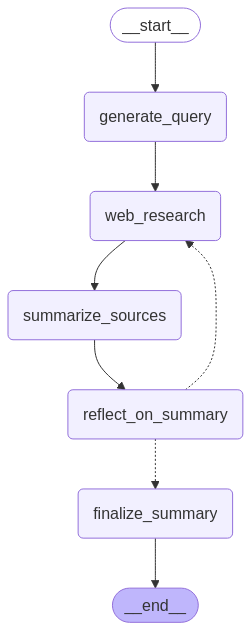

In [77]:
from IPython.display import Image, display
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [79]:
# Test
research_input = SummaryStateInput(
    research_topic="什麼是PCB?"
)
summary = graph.invoke(research_input)

In [80]:
summary

{'running_summary': '## Summary\n\nPrinted circuit board (PCB) 是一種由多層材料組成的電路板，主要用於製造電子device。它可以分為單層、雙層和多層，單層 PCB適合簡單的電子device，如家電器具，而雙層和多層 PCB則適合更複雜的 hardware，如 computer graphics cards 和 motherboards。\n\n選擇合適的材料對於PCB的性能、持久性和功能性至關重要。FR4是最常用的PCB基材之一，具有優異的特性，但也存在其他材料的選擇，例如金屬、多層材料等。了解不同材料的優缺點，可以為電子device設計提供更好的選擇。\n\n金屬芯 PCB 和 FR4 PCB 是兩種不同的材料，各有其優缺點。金屬芯 PCB 更適合需要出色熱管理的高功率專案，而 FR4 PCB 最適合設計複雜的低功耗、經濟型設備。在做出最終決定之前，請考慮最重要的因素—成本、熱或耐用性。\n\n金屬芯 pcb (mcpcb) 是具有金屬芯的電路板。金屬層有助於 熱管理，這對於高功率設備至關重要。 mcpcb 有何不同？ 傳統的 pcb，例如 fr-4 和 cem-3，使用不能很好地耐熱的材料。 它們適合一般用途，但難以應對熱敏感應用。\n\nFR-4 是最流行的 PCB 材料，由於其平衡強度、熱穩定性和成本效益。它包括玻璃纖維布嵌入環氧樹脂中，形成堅固的阻燃層壓板。 FR-4 的工作溫度範圍為 130°c 至 180°c，在中等溫度下表現良好。\n\n ### Sources:\n* Printed circuit board - Wikipedia : https://en.wikipedia.org/wiki/Printed_circuit_board\n* What is printed circuit board (PCB)? | Definition from TechTarget : https://www.techtarget.com/whatis/definition/printed-circuit-board-PCB\n* PCB Definition - What is a PCB? - TechTerms.com : https://techterms.com/definitio